Гипотеза 1: У задержанных заказов оценки ниже, чем у доставленных вовремя. 

Сравним:
- среднюю и медианную оценку;
- долю низких оценок;
- распределение review_score;
- группы статистическим тестом Манна — Уитни.

Гипотеза 2: Чем дольше длится доставка, тем ниже оценка клиента. 

Рассчитаем корреляцию Спирмена между: delivery_days и 
review_score

Гипотеза 3: Доля низких оценок связана с фактом задержки доставки. 

Сделаем признак: low_review = review_score <= 2

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    mannwhitneyu,
    spearmanr,
    chi2_contingency,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")
PROCESSED_PATH = Path("../data/processed")
FIGURES_PATH = Path("../reports/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
orders = pd.read_csv(
    PROCESSED_PATH / "orders_enriched.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]
)

In [5]:
analysis = orders[(orders["order_status"] == "delivered") & (orders["review_score"].notna()) & (orders["delivery_days"].notna()) & (orders["is_late"].notna())].copy()
analysis["low_review"] = analysis["review_score"] <= 2
analysis[["review_score", "delivery_days", "is_late", "low_review",]].describe(include="all")

,review_score,delivery_days,is_late,low_review
count,95824.000,95824.000,95824,95824
unique,NaN,NaN,2,2
top,NaN,NaN,False,False
freq,NaN,NaN,88163,83588
mean,4.156,12.517,NaN,NaN
std,1.284,9.461,NaN,NaN
min,1.000,0.533,NaN,NaN
25%,4.000,6.757,NaN,NaN
50%,5.000,10.206,NaN,NaN
75%,5.000,15.664,NaN,NaN


Гипотеза 1: оценки задержанных заказов ниже

In [6]:
review_by_delivery = analysis.groupby("is_late").agg(orders_count=("order_id", "nunique"), average_review=("review_score", "mean"), median_review=("review_score", "median"), low_review_rate=("low_review", "mean"), average_delivery_days=("delivery_days", "mean"),)
review_by_delivery

,orders_count,average_review,median_review,low_review_rate,average_delivery_days
is_late,,,,,
False,88163,4.294,5.000,0.092,10.878
True,7661,2.567,2.000,0.540,31.379


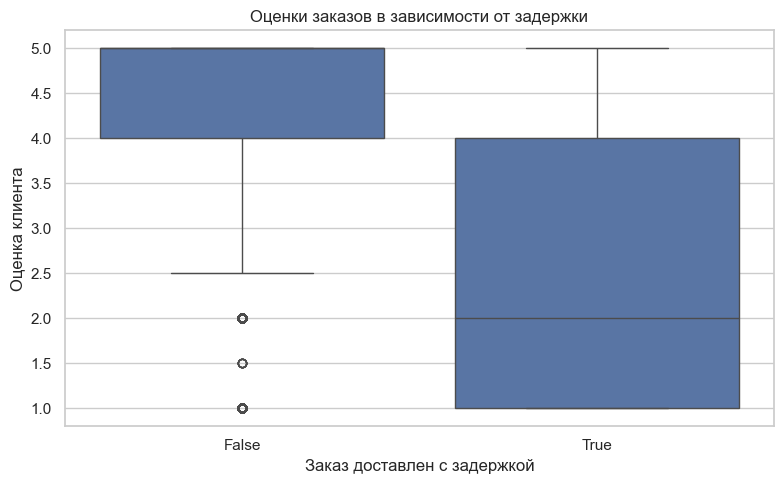

In [7]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=analysis,
    x="is_late",
    y="review_score"
)

plt.title("Оценки заказов в зависимости от задержки")
plt.xlabel("Заказ доставлен с задержкой")
plt.ylabel("Оценка клиента")
plt.tight_layout()
plt.show()

H0: распределения оценок в двух группах не различаются.

H1: распределения оценок различаются.

In [9]:
on_time_reviews = analysis.loc[
    analysis["is_late"] == False,
    "review_score"
]

late_reviews = analysis.loc[
    analysis["is_late"] == True,
    "review_score"
]
mann_whitney_result = mannwhitneyu(
    late_reviews,
    on_time_reviews,
    alternative="two-sided"
)

print(
    "Mann–Whitney statistic:",
    mann_whitney_result.statistic
)

print(
    "p-value:",
    mann_whitney_result.pvalue
)

Mann–Whitney statistic: 150680825.5
p-value: 0.0


In [10]:
ALPHA = 0.05

if mann_whitney_result.pvalue < ALPHA:
    print("H0 отвергается: между группами обнаружены статистически значимые различия.")
else:
    print("Недостаточно оснований отвергнуть H0.")

H0 отвергается: между группами обнаружены статистически значимые различия.


In [11]:
average_review_difference = (
    late_reviews.mean()
    - on_time_reviews.mean()
)

print(
    f"Разница средних оценок: "
    f"{average_review_difference:.3f}"
)

Разница средних оценок: -1.728


Гипотеза 2: связь срока доставки с оценкой

In [13]:
spersman_result = spearmanr(analysis["delivery_days"], analysis["review_score"], nan_policy="omit")
print("Spearman correlation: ", spersman_result.statistic)
print("p-value:", spersman_result.pvalue)

Spearman correlation:  -0.23480054753086033
p-value: 0.0


In [16]:
analysis["delivery_group"] = pd.cut(analysis["delivery_days"], bins=[0, 7, 14, 21, 30, np.inf], labels=["0-7", "8-14", "15-21", "22-30", "31+",], include_lowest=True)
delivery_group_summary = analysis.groupby("delivery_group", observed=True, as_index=False).agg(orders_count=("order_id", "nunique"), average_review=("review_score", "mean"), low_review_rate=("low_review", "mean"),)
delivery_group_summary

,delivery_group,orders_count,average_review,low_review_rate
0,0-7,25933,4.418,0.074
1,8-14,39997,4.312,0.089
2,15-21,17582,4.140,0.116
3,22-30,7882,3.607,0.243
4,31+,4430,2.254,0.629


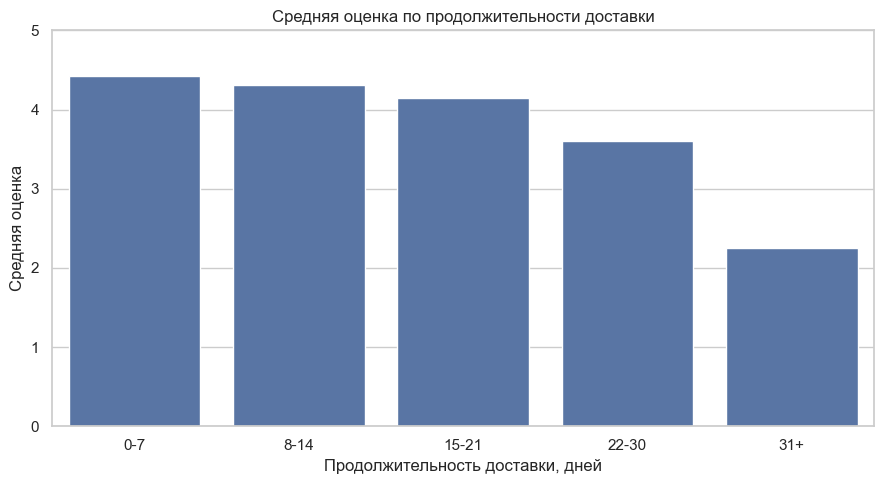

In [17]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=delivery_group_summary,
    x="delivery_group",
    y="average_review"
)

plt.title("Средняя оценка по продолжительности доставки")
plt.xlabel("Продолжительность доставки, дней")
plt.ylabel("Средняя оценка")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

Гипотеза 3: задержка и низкая оценка

In [18]:
contingency_table = pd.crosstab(analysis["is_late"], analysis["low_review"])
contingency_table

low_review,False,True
is_late,,
False,80063,8100
True,3525,4136


In [20]:
chi2, p_value, degrees_of_freedom, expected = (chi2_contingency(contingency_table))
print("Chi-square:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square: 12696.532367511776
p-value: 0.0
Degrees of freedom: 1


In [21]:
observations_count = contingency_table.to_numpy().sum()
rows_count, columns_count = contingency_table.shape
cramers_v = np.sqrt(chi2 / (observations_count*min(rows_count - 1, columns_count - 1)))
print(f"Cramer's V: {cramers_v:.3f}")

Cramer's V: 0.364


## Выводы пятого этапа

1. Для анализа выбраны 95 824 доставленных заказа с известными сроками доставки и оценками клиентов.

2. Средняя оценка заказов, доставленных вовремя, составила **4,294**, а задержанных заказов — **2,567**. Медианная оценка своевременных доставок равна **5**, задержанных — **2**.

3. Доля низких оценок от 1 до 2 баллов среди своевременных доставок составила **9,2%**, а среди задержанных — **54,0%**. Таким образом, у задержанных заказов доля низких оценок приблизительно в 5,9 раза выше.

4. Тест Манна — Уитни показал наличие статистически значимых различий между распределениями оценок своевременных и задержанных заказов (`p-value < 0,001`). Нулевая гипотеза об отсутствии различий была отвергнута.

5. Корреляция Спирмена между продолжительностью доставки и оценкой составила **-0.235**, что указывает на **СЛАБУЮ** отрицательную связь. По мере увеличения продолжительности доставки средняя оценка последовательно снижается: с **4,418** для доставки за 0–7 дней до **2,254** для доставки продолжительностью более 31 дня.

6. Критерий хи-квадрат показал наличие статистически значимой связи между задержкой доставки и получением низкой оценки (`χ² = 12 696,53`, `p-value < 0,001`). Среди 7 661 задержанного заказа 4 136 получили оценку от 1 до 2 баллов.

7. Cramér’s V составил **0,364**, что соответствует среднему размеру эффекта. Следовательно, обнаруженная связь имеет не только статистическую, но и практическую значимость.

8. Результаты показывают выраженную связь задержек с клиентской неудовлетворённостью, но не доказывают причинное влияние. На оценки также могут влиять качество товара, работа продавца, упаковка, цена и другие факторы.

9. С практической точки зрения рекомендуется контролировать долю задержанных заказов, средний срок доставки и долю оценок 1–2 балла. Дополнительно следует исследовать регионы, продавцов и товарные категории с наиболее частыми задержками и низкими оценками.